<a href="https://colab.research.google.com/github/ojohnso3-oss/ojohnso3-INST414/blob/main/Lab14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%matplotlib inline

In [2]:
import pandas as pd
import numpy as np
import json

In [3]:
actor_name_map = {}
movie_actor_map = {}

with open("/content/sample_data/imdb_movies_2000to2022.prolific.json", "r") as in_file:
    for line in in_file:

        this_movie = json.loads(line)
        # Skip movies with no ratings
        if len(this_movie["rating"]) == 0:
            continue

        for actor_id,actor_name in this_movie['actors']:
            actor_name_map[actor_id] = actor_name

        # Finished with this film
        movie_actor_map[this_movie["imdb_id"]] = ({
            "movie": this_movie["title"],
            "actors": {a[0] for a in this_movie['actors']},
            "genres": this_movie["genres"],
            "rating": this_movie["rating"]["avg"],
        })

In [8]:
movie_ids = list(movie_actor_map.keys())

In [10]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer(sparse_output = True)
movie_actor_matrix = mlb.fit_transform(
    [movie_actor_map[movie_id]["actors"] for movie_id in movie_ids])

movie_actor_df = pd.DataFrame.sparse.from_spmatrix(
    movie_actor_matrix,
    index=movie_ids,
    columns=mlb.classes_
)

In [11]:
from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

In [12]:
dr_model = TruncatedSVD(n_components=2)

In [13]:
trans_data = dr_model.fit_transform(movie_actor_df)

<Axes: xlabel='0', ylabel='1'>

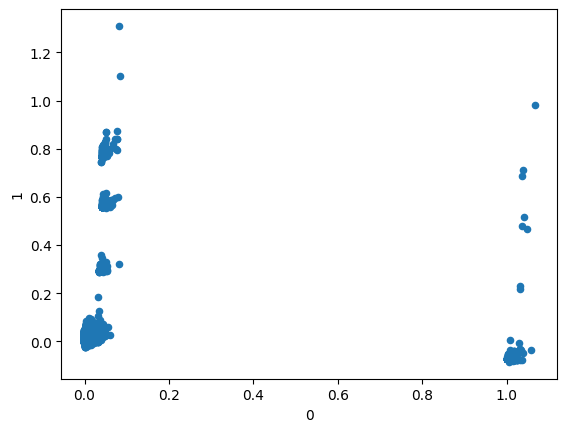

In [14]:
pd.DataFrame(trans_data).plot.scatter(x=0, y=1)

In [15]:
from sklearn.neighbors import KNeighborsRegressor